In [1]:
import pandas as pd
import mlflow
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Layer, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import *
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import datetime
import time
import os
import json

2025-04-01 19:58:38.614631: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 19:58:38.622666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743551918.631020 4019537 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743551918.633459 4019537 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743551918.640302 4019537 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
base_path = "/home/subha/aiwork/project"
mlflow_storage = "mlflow"
experiment_number = f"EXP_{str(int(time.time()))}"
os.mkdir(f"{base_path}/completed_models/{experiment_number}")
print(f"Experment: {experiment_number}")

Experment: EXP_1743551920


In [3]:
def save_complete_model(model, model_type, custom_name=None):
    """
    Save the complete model including architecture, weights, and optimizer state
    
    Args:
        model: Keras model instance
        model_type (str): Type of the model
        custom_name (str, optional): Custom name for the model
        
    Returns:
        str: Path to the saved model
    """
    try:
        epoch_time = str(int(time.time()))
        model_name = f"{custom_name}.keras"
        save_path = os.path.join(base_path, "completed_models", experiment_number)
        model_path = os.path.join(save_path,model_name)
        
        # Save the complete model
        model.save(model_path)
        
        # Save additional metadata
        metadata = {
            "model_type": model_type,
            "save_date": datetime.datetime.now().isoformat(),
            "keras_version": tf.keras.__version__,
            "model_name": model_name
        }
        
        metadata_path = os.path.join(save_path, f"metadata_{custom_name}.json")
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=4)
            
        print(f"Model successfully saved to: {save_path}")
        return save_path
        
    except Exception as e:
        print(f"Error saving complete model: {str(e)}")
        raise

In [4]:
# ---------------------- 1. Preprocessing (Tokenization) ----------------------
def preprocess_text(texts,tokenizer=None, max_words=10000, max_len=300):
    """
    Tokenizes and pads the input text data.

    Args:
        texts (pd.Series): A pandas Series containing the text data.
        max_words (int): The maximum number of words to keep in the vocabulary.
        max_len (int): The maximum length of each sequence.

    Returns:
        tuple: A tuple containing the tokenized and padded sequences (numpy array)
               and the fitted Tokenizer object.
    """
    epoch_time = str(int(time.time()))
    tkn_name = f"tokenizer.json"
    save_path = os.path.join(base_path, "completed_models",experiment_number,tkn_name)
    
    if tokenizer is None:
        tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
        tokenizer.fit_on_texts(texts)
        tokenizer_config = tokenizer.to_json()
        # Saving the Tokenizer
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(tokenizer_config)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded_sequences, tokenizer

In [5]:
# ---------------------- 2. Model Building (LSTM with Attention) ----------------------
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                  shape=(input_shape[-1], 1),
                                  initializer='random_normal',
                                  trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                  shape=(input_shape[1], 1),
                                  initializer='zeros',
                                  trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        et = tf.tanh(tf.matmul(x, self.W) + self.b)
        at = tf.nn.softmax(tf.squeeze(et, axis=-1))
        at_expanded = tf.expand_dims(at, axis=-1)
        context_vector = x * at_expanded
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

In [6]:
def build_lstm_attention_model(rnn_type, vocab_size, embedding_dim=100, learning_rate=0.001, number_of_neurons=32, activation='relu',max_len=300):
    """
    Builds an LSTM model with an attention mechanism for sentiment analysis.

    Args:
        vocab_size (int): The size of the vocabulary.
        embedding_dim (int): The dimensionality of the embedding layer.
        lstm_units (int): The number of units in the LSTM layer.
        max_len (int): The maximum length of the input sequences.

    Returns:
        tf.keras.Model: The compiled LSTM with Attention model.
    """
    
    input_layer = Input(shape=(max_len,))
    embedding_layer = Embedding(vocab_size, embedding_dim)(input_layer)
    lstm_layer = LSTM(number_of_neurons, return_sequences=True)(embedding_layer)
    lstm_dropout = Dropout(0.5)(lstm_layer)
    attention_layer = AttentionLayer()(lstm_dropout)
    output_dropout = Dropout(0.5)(attention_layer)
    output_layer = Dense(1, activation='sigmoid')(attention_layer)



    model = Model(inputs=input_layer, outputs=output_layer)

    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer,
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

    return model

In [7]:
# ---------------------- 3. Model Training ----------------------
def train_model(model, X_train, y_train, X_val, y_val, epochs=10, early_stopping_ind=False, batch_size=32):
    """
    Trains the given Keras model.

    Args:
        model (tf.keras.Model): The Keras model to train.
        X_train (np.array): Training input data.
        y_train (np.array): Training target data.
        X_val (np.array): Validation input data.
        y_val (np.array): Validation target data.
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.

    Returns:
        tf.keras.callbacks.History: The training history object.
    """
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', 
                                 patience=3,
                                 restore_best_weights=True)
    
    # Variable rate
    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-5)

    if early_stopping_ind:
        callbacks = [early_stopping,lr_scheduler]
    else:
        callbacks = [lr_scheduler]
    
    
    history = model.fit(X_train, 
                        y_train, 
                        epochs=epochs, 
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),
                        verbose=1,
                        callbacks=callbacks
                       )
    model.summary()

    save_path = save_complete_model(
                        model=model,
                        model_type="lstm_attention",
                        custom_name=f"sentiment_analysis_lstm_attention"
                    )
    print(f"The Model is saved in {save_path}")
    
    return history

In [8]:
# ---------------------- 4. Model Evaluation ----------------------
def evaluate_model(model, X_val, y_val):
    """
    Evaluates the trained Keras model on the validation data.

    Args:
        model (tf.keras.Model): The trained Keras model.
        X_val (np.array): Validation input data.
        y_val (np.array): Validation target data.

    Returns:
        tuple: A tuple containing the loss and accuracy on the validation set.
    """
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Loss: {loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    return loss, accuracy

In [9]:
# ---------------------- 5. Model Scoring ----------------------
def score_model(model, texts, tokenizer, max_len=300, threshold=0.5):
    """
    Scores new text data using the trained model.

    Args:
        model (tf.keras.Model): The trained Keras model.
        texts (list or pd.Series): A list or pandas Series of text to score.
        tokenizer (Tokenizer): The tokenizer fitted on the training data.
        max_len (int): The maximum length of the input sequences.
        threshold (float): The threshold for classifying sentiment (default 0.5).

    Returns:
        pd.DataFrame: A DataFrame containing the original text, predicted probability,
                      and predicted sentiment (0 or 1).
    """
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    predictions = model.predict(padded_sequences)
    predicted_sentiments = np.where(predictions >= threshold, 1, 0).flatten()
    results_df = pd.DataFrame({'cleaned_text': texts,
                               'predicted_probability': predictions.flatten(),
                               'predicted_sentiment': predicted_sentiments})
    return results_df

In [10]:
# ---------------------- 6. Visualization of Training History ----------------------
def plot_training_history(history, model_name):
    """
    Plot training and validation metrics
    """
    print("=======================================================================================")
    print("I am in plot_training_history")
    print("=======================================================================================")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),dpi=100)
    
    # Turn interactive plotting off
    #plt.ioff()
    
    # Plot accuracy
    #ax1.set_ylim(0, 1.5)
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title(f'{model_name} - Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'])
    
    # Plot loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title(f'{model_name} - Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'])
    
    plt.tight_layout()
    return fig



In [11]:
remote_server_uri = "http://172.22.74.11:5000/"
mlflow.set_tracking_uri(remote_server_uri)
def run(X_train, y_train, X_val, X_test, y_val, y_test, vocab=5000,embedding_dim=100,learning_rate=0.001,epochs=15,early_stop=False,batch_size=32,activation_func='relu',number_of_neurons=32,experiment_num="EXP-000"):
    """
    Compare different RNN architectures
    """
    results = {}
    model_types = ['lstm_attention'] # Removed 'bilstm' for simplicity as attention mechanism wasn't clearly defined
    tokenizer = None # Initialize tokenizer here to use the same one across models

    for rnn_type in model_types:
        with mlflow.start_run(run_name=f"Sentiment Analysis - {rnn_type.upper()}"):
            print(f"Training model: {rnn_type.upper()}")
            mlflow.log_param("rnn_type", rnn_type)
            mlflow.log_param("vocab_size", vocab)
            mlflow.log_param("embedding_dim", embedding_dim)
            mlflow.log_param("learning_rate", learning_rate)
            mlflow.log_param("epochs", epochs)
            mlflow.log_param("early_stop", early_stop)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("activation_func", activation_func)
            mlflow.log_param("number_of_neurons", number_of_neurons)
            mlflow.log_param("data_size", 'small')
            mlflow.log_param("experiment_number", experiment_num)

            model = build_lstm_attention_model(rnn_type, 
                                     vocab, 
                                     embedding_dim, 
                                     learning_rate, 
                                     number_of_neurons, 
                                     activation_func) 
            
            history = train_model( model, 
                                          X_train, 
                                          y_train, 
                                          X_val, 
                                          y_val, 
                                          epochs, 
                                          early_stop, 
                                          batch_size
                                    )
            
            test_loss,test_accuracy = evaluate_model(model, X_test, y_test)

            mlflow.log_metric("test_loss", test_loss)
            mlflow.log_metric("test_accuracy", test_accuracy)
            
            y_pred = (model.predict(X_test) > 0.5).astype(int)

            # Log training history metrics
            for epoch in range(len(history.history['loss'])):
                mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
                mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)
                mlflow.log_metric("train_accuracy", history.history['accuracy'][epoch], step=epoch)
                mlflow.log_metric("val_accuracy", history.history['val_accuracy'][epoch], step=epoch)

            # Log classification report and confusion matrix as artifacts (or as json)
            report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
            cm = confusion_matrix(y_test, y_pred)

            with open(f"{mlflow_storage}/classification_report_{rnn_type}.json", "w") as f:
                json.dump(report, f, indent=4)
            np.save(f"{mlflow_storage}/confusion_matrix_{rnn_type}.npy", cm)

            mlflow.log_artifact(f"{mlflow_storage}/classification_report_{rnn_type}.json")
            mlflow.log_artifact(f"{mlflow_storage}/confusion_matrix_{rnn_type}.npy")

            # Log the trained model
            mlflow.keras.log_model(model, f"model_{rnn_type}")

            results[rnn_type] = {
                'history': history,
                'test_loss': test_loss,
                'test_accuracy': test_accuracy,
                'predictions': y_pred,
                'classification report': report,
                'confusion_matrix': cm
            }


    return results, tokenizer


In [12]:
X_test_ = pd.read_parquet('output/cleandata/large/test_data_sample/', engine='pyarrow' )
X_train_ = pd.read_parquet('output/cleandata/large/train_data_sample/', engine='pyarrow' )
X_val_ = pd.read_parquet('output/cleandata/large/val_data_sample/', engine='pyarrow' )

In [13]:
## Train

X_text_train = list(X_train_["cleaned_text"])
y_train = np.array(X_train_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_train, tokenizer = preprocess_text(X_text_train)

## Test

X_text_test = list(X_test_["cleaned_text"])
y_test = np.array(X_test_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_test, tokenizer = preprocess_text(X_text_test,tokenizer)

## Val

X_text_val = list(X_val_["cleaned_text"])
y_val = np.array(X_val_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_val, tokenizer = preprocess_text(X_text_val,tokenizer)

# Vocabulary size
vocab = len(tokenizer.word_index) + 1
print(vocab)

422795


In [14]:
results, tokenizer = run(X_train, y_train, X_val, X_test, y_val, y_test, vocab
                                    ,embedding_dim=150
                                    ,learning_rate=0.001
                                    ,epochs=10
                                    ,early_stop=True
                                    ,batch_size=64
                                    ,activation_func='relu'
                                    ,number_of_neurons=64
                                    ,experiment_num=experiment_number) 

Training model: LSTM_ATTENTION


I0000 00:00:1743551934.980917 4019537 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9517 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/10


I0000 00:00:1743551936.871417 4019695 cuda_dnn.cc:529] Loaded cuDNN version 90701


5625/5625 ━━━━━━━━━━━━━━━━━━━━ 205s 36ms/step - accuracy: 0.8272 - loss: 0.3756 - val_accuracy: 0.9231 - val_loss: 0.1931 - learning_rate: 0.0010
Epoch 2/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 202s 36ms/step - accuracy: 0.9352 - loss: 0.1688 - val_accuracy: 0.9319 - val_loss: 0.1765 - learning_rate: 0.0010
Epoch 3/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 200s 36ms/step - accuracy: 0.9500 - loss: 0.1353 - val_accuracy: 0.9312 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 4/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 197s 35ms/step - accuracy: 0.9608 - loss: 0.1104 - val_accuracy: 0.9288 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 5/10
5624/5625 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9702 - loss: 0.0871  
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 200s 36ms/step - accuracy: 0.9702 - loss: 0.0871 - val_accuracy: 0.9266 - val_loss: 0.2086 - learning_rate: 0.0010


...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 126,949,440 (484.27 MB)

Model successfully saved to: /home/subha/aiwork/project/completed_models/EXP_1743551920
The Model is saved in /home/subha/aiwork/project/completed_models/EXP_1743551920
Validation Loss: 0.1706
Validation Accuracy: 0.9372
618/618 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


2025/04/01 20:15:50 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/04/01 20:15:55 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp_bnmp0iq/model, flavor: keras). Fall back to return ['keras==3.8.0']. Set logging level to DEBUG to see the full traceback. 
2025/04/01 20:15:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Sentiment Analysis - LSTM_ATTENTION at: http://172.22.74.11:5000/#/experiments/0/runs/e83479f2bf68486b8137efa5de7fad6b
🧪 View experiment at: http://172.22.74.11:5000/#/experiments/0


I am in plot_training_history


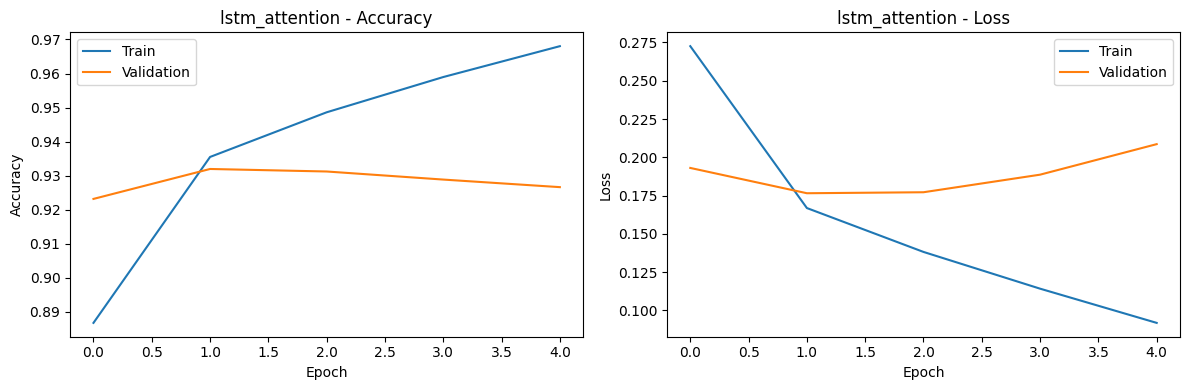

In [15]:
# Plot the training history
storage = f"{base_path}/completed_models/{experiment_number}"
#plot_training_history(results[model_types[0]]["history"], model_types[0].upper()).show()
fig_history_1 = plot_training_history(results["lstm_attention"]["history"], 'lstm_attention')
fig_history_1.savefig(f"{storage}/training_history_lstm_attention.png")